# Prediction for heart disease Using ML
## Author : Eng. Amr Samir

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 

In [4]:
df=pd.read_csv(r"C:\Users\Admin\Desktop\Prediction for heart disease project\heart_cleveland_upload.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [7]:
#check if there is any missing values 
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

In [11]:
print(df['condition'].value_counts())

condition
0    160
1    137
Name: count, dtype: int64


<Axes: xlabel='condition', ylabel='count'>

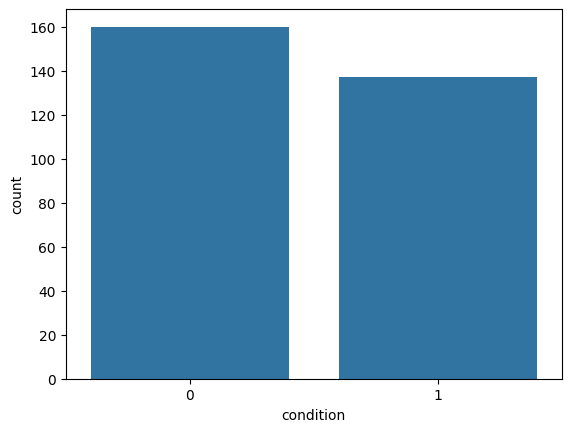

In [8]:
sns.countplot(x='condition',data=df)

<Axes: >

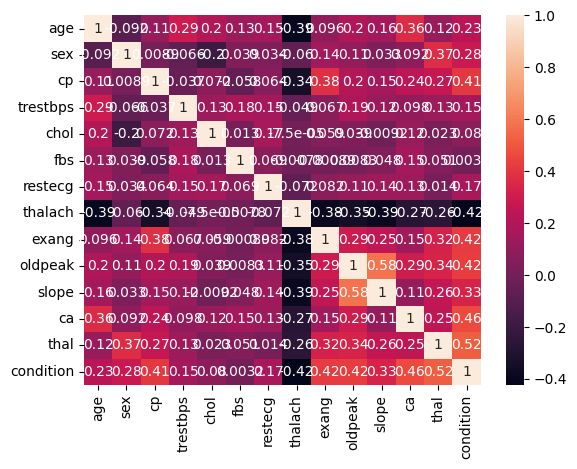

In [9]:
sns.heatmap(df.corr(),annot=True)

<Axes: xlabel='age', ylabel='Count'>

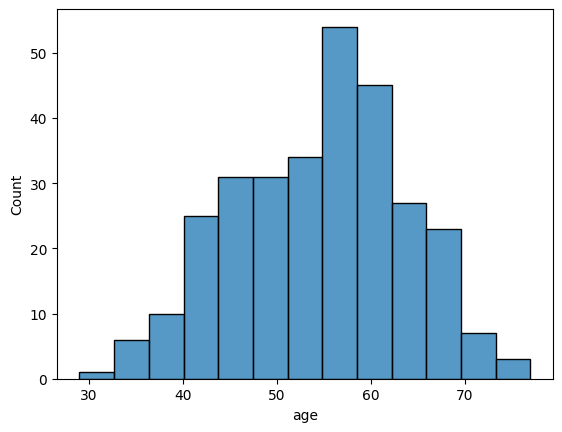

In [10]:
sns.histplot(df['age'])

<Axes: xlabel='condition', ylabel='age'>

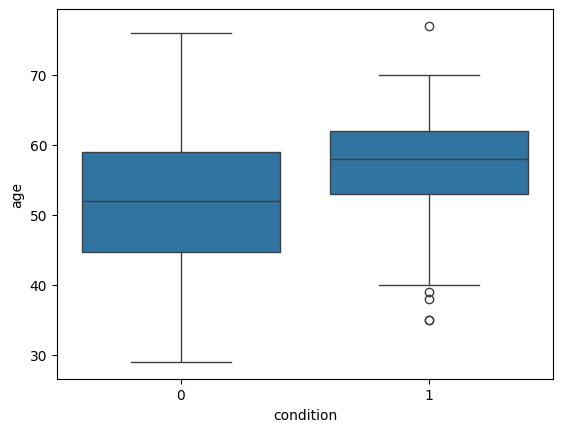

In [12]:
sns.boxplot(x='condition',y='age',data=df)

Text(0.5, 1.0, 'Relationship between chest pain and condition')

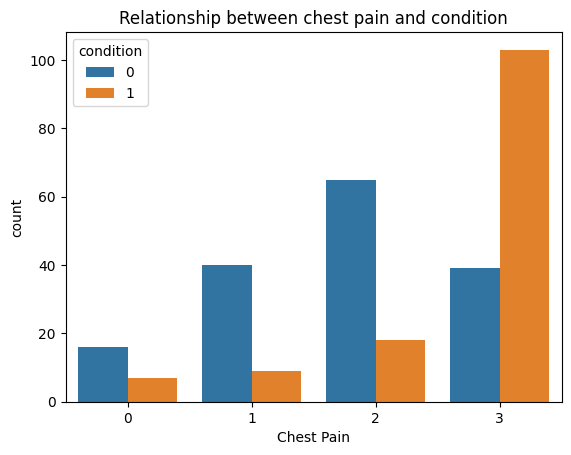

In [19]:
plt.figure()
sns.countplot(x='cp',hue='condition',data=df)
plt.xlabel('Chest Pain')
plt.title('Relationship between chest pain and condition')

<Axes: xlabel='chol', ylabel='Count'>

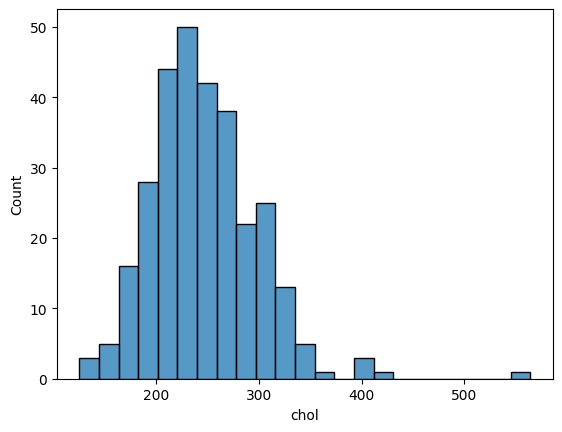

In [14]:
sns.histplot(df['chol'])

<Axes: xlabel='chol', ylabel='count'>

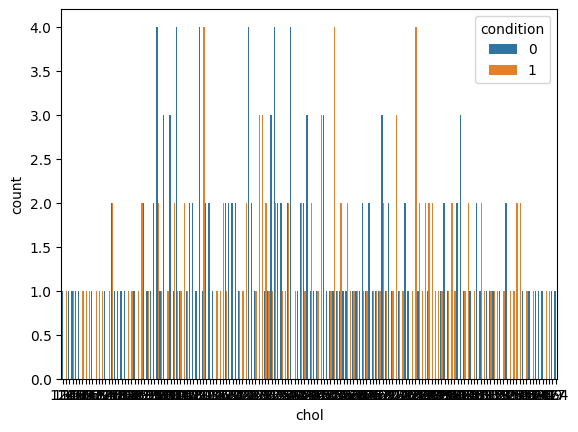

In [15]:
sns.countplot(x='chol',hue='condition',data=df)

In [17]:
x=df.drop('condition',axis=1)
y=df['condition']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [21]:
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

### Logistic Regression Model

In [23]:
lr_params={'C':[0.01,0.1,1,10,100]}
lr=GridSearchCV(estimator=LogisticRegression(max_iter=1000),param_grid=lr_params,cv=5,scoring='accuracy')
lr.fit(x_train,y_train)
print("Best Logistic Regresstion Parameters",lr.best_params_)

Best Logistic Regresstion Parameters {'C': 0.01}


### Random Forest Model

In [24]:
rf_params={'n_estimators':[50,100,150,200],'max_depth':[3,5,7,None]}
rf=GridSearchCV(estimator=RandomForestClassifier(),param_grid=rf_params,cv=5,scoring='accuracy')
rf.fit(x_train,y_train)
print('Best Random Forest Parameters:', rf.best_params_)

Best Random Forest Parameters: {'max_depth': 3, 'n_estimators': 50}


### XGBoost Model

In [26]:
xgb_params={'n_estimators':[50,100,150],'max_depth':[3,5,7],'learning_rate':[0.01,0.1]}
xgb=GridSearchCV(estimator=XGBClassifier(eval_metric='logloss'),param_grid=xgb_params,cv=5,scoring='accuracy')
xgb.fit(x_train,y_train)
print('Best XGB parameters:',xgb.best_params_)

Best XGB parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


In [27]:
from sklearn.metrics import classification_report,roc_auc_score , RocCurveDisplay , confusion_matrix

In [34]:
lr_pred=lr.predict(x_test)
rf_pred=rf.predict(x_test)
xgb_pred=xgb.predict(x_test)

In [35]:
print('Classification Report for Logistic Regression Prediction')
print(classification_report(y_test,lr_pred))

Classification Report for Logistic Regression Prediction
              precision    recall  f1-score   support

           0       0.81      0.97      0.88        30
           1       0.96      0.77      0.85        30

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.87        60
weighted avg       0.88      0.87      0.87        60



In [36]:
print('Classification Report for Random Forest Prediction')
print(classification_report(y_test,rf_pred))

Classification Report for Random Forest Prediction
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        30
           1       0.85      0.73      0.79        30

    accuracy                           0.80        60
   macro avg       0.81      0.80      0.80        60
weighted avg       0.81      0.80      0.80        60



In [37]:
print('Classification Report for XGB Prediction')
print(classification_report(y_test,xgb_pred))

Classification Report for XGB Prediction
              precision    recall  f1-score   support

           0       0.81      0.97      0.88        30
           1       0.96      0.77      0.85        30

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.87        60
weighted avg       0.88      0.87      0.87        60



In [38]:
print('Logistic Regression ROC/AUC',roc_auc_score(y_test,lr.predict_proba(x_test)[:,1]))

print('Random Forest ROC/AUC',roc_auc_score(y_test,rf.predict_proba(x_test)[:,1]))

print('XGB Boost ROC/AUC',roc_auc_score(y_test,xgb.predict_proba(x_test)[:,1]))


Logistic Regression ROC/AUC 0.9166666666666667
Random Forest ROC/AUC 0.9044444444444445
XGB Boost ROC/AUC 0.8783333333333333


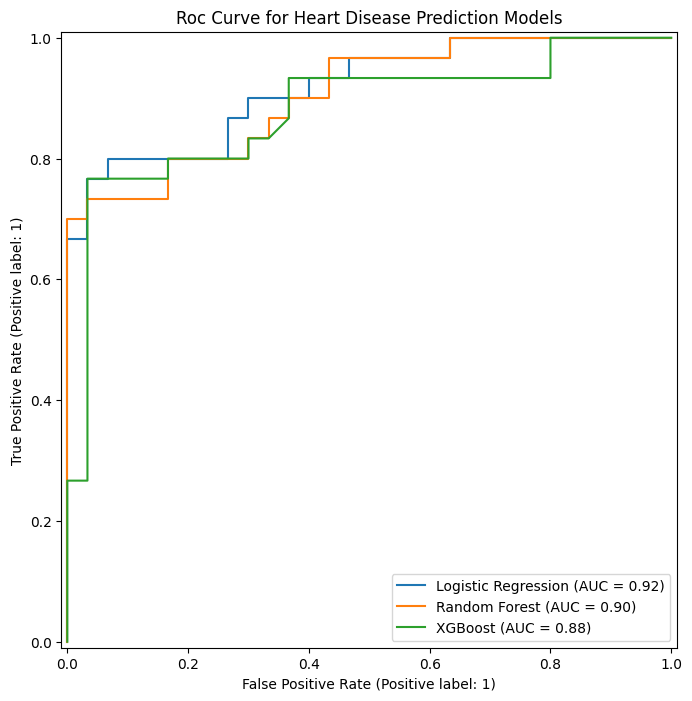

In [39]:
fig,ax=plt.subplots(figsize=(10,8))
RocCurveDisplay.from_estimator(lr,x_test,y_test,ax=ax,name='Logistic Regression')
RocCurveDisplay.from_estimator(rf,x_test,y_test,ax=ax,name='Random Forest')
RocCurveDisplay.from_estimator(xgb,x_test,y_test,ax=ax,name='XGBoost')
ax.set_title('Roc Curve for Heart Disease Prediction Models')
plt.show()

In [45]:
importances=rf.best_estimator_.feature_importances_
feature_names=x.columns
feature_importances_df=pd.DataFrame({'Feature': feature_names,'Importance': importances})
feature_importances_df=feature_importances_df.sort_values(by='Importance', ascending=False)
feature_importances_df 

,Feature,Importance
2,cp,0.233209
12,thal,0.139408
11,ca,0.115209
7,thalach,0.113474
8,exang,0.096808
10,slope,0.088913
9,oldpeak,0.078548
0,age,0.053377
1,sex,0.027552
4,chol,0.025815


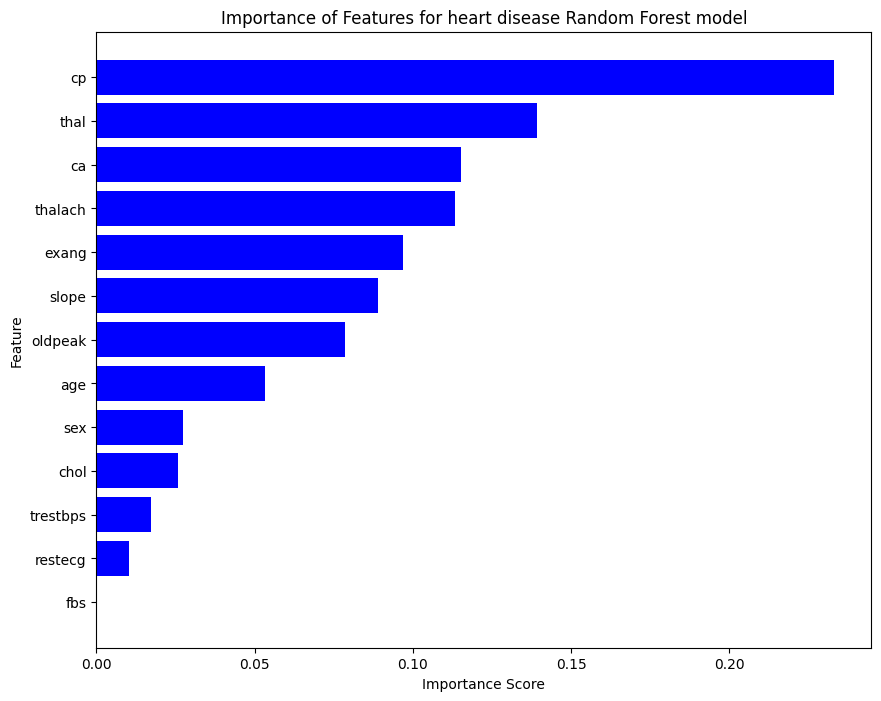

In [48]:
plt.figure(figsize=(10,8))
plt.barh(feature_importances_df['Feature'],feature_importances_df['Importance'],color='blue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Importance of Features for heart disease Random Forest model')
plt.gca().invert_yaxis()
plt.show()

In [49]:
importances_xgb=xgb.best_estimator_.feature_importances_
feature_names=x.columns
feature_importances_df=pd.DataFrame({'Feature': feature_names,'Importance': importances_xgb})
feature_importances_df=feature_importances_df.sort_values(by='Importance', ascending=False)
feature_importances_df 

,Feature,Importance
2,cp,0.434303
11,ca,0.101791
12,thal,0.091965
8,exang,0.076082
10,slope,0.067719
0,age,0.054276
9,oldpeak,0.052020
7,thalach,0.043280
4,chol,0.036772
1,sex,0.021095


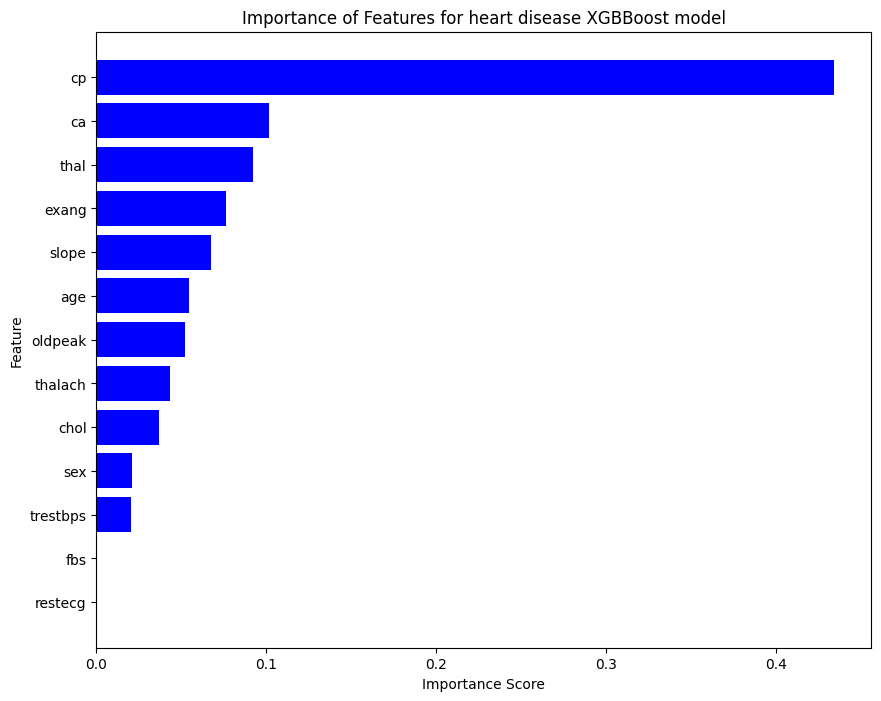

In [50]:
plt.figure(figsize=(10,8))
plt.barh(feature_importances_df['Feature'],feature_importances_df['Importance'],color='blue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Importance of Features for heart disease XGBBoost model')
plt.gca().invert_yaxis()
plt.show()

In [52]:
importances_lr=lr.best_estimator_.coef_[0]
feature_names=x.columns
feature_importances_df_lr=pd.DataFrame({'Feature':feature_names,'Coefficients':importances_lr})
feature_importances_df_lr['abs_importance']=feature_importances_df_lr['Coefficients'].abs()
feature_importances_df_lr=feature_importances_df_lr.sort_values(by='abs_importance',ascending=False)
feature_importances_df_lr

,Feature,Coefficients,abs_importance
11,ca,0.268931,0.268931
12,thal,0.239974,0.239974
2,cp,0.216497,0.216497
8,exang,0.200315,0.200315
7,thalach,-0.173680,0.173680
9,oldpeak,0.168312,0.168312
10,slope,0.160463,0.160463
1,sex,0.137513,0.137513
6,restecg,0.076871,0.076871
0,age,0.048875,0.048875


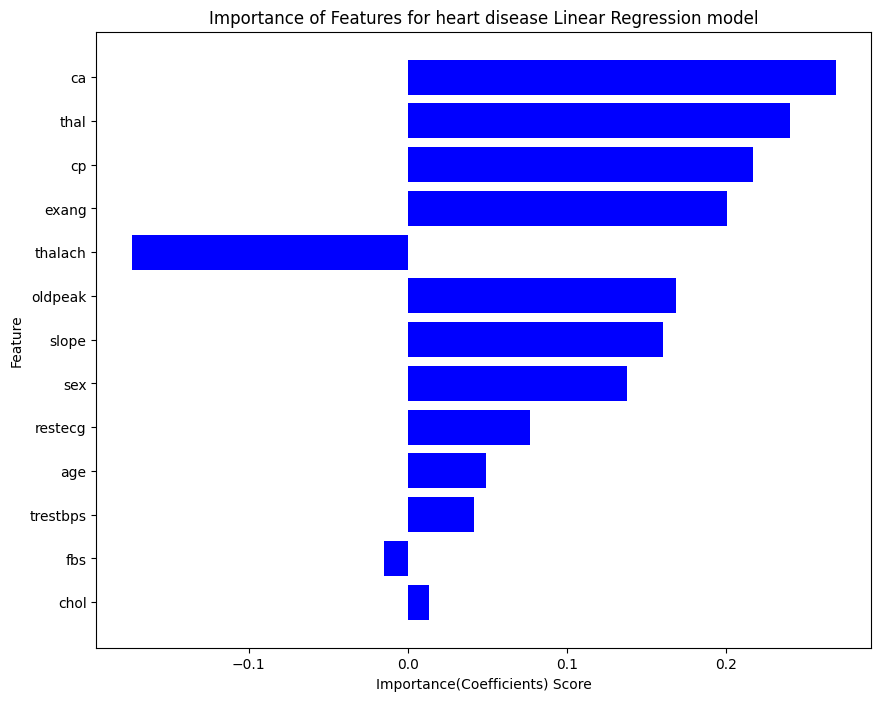

In [54]:
plt.figure(figsize=(10,8))
plt.barh(feature_importances_df_lr['Feature'],feature_importances_df_lr['Coefficients'],color='blue')
plt.xlabel('Importance(Coefficients) Score')
plt.ylabel('Feature')
plt.title('Importance of Features for heart disease Linear Regression model')
plt.gca().invert_yaxis()
plt.show()

# Author: Eng. Amr Samir